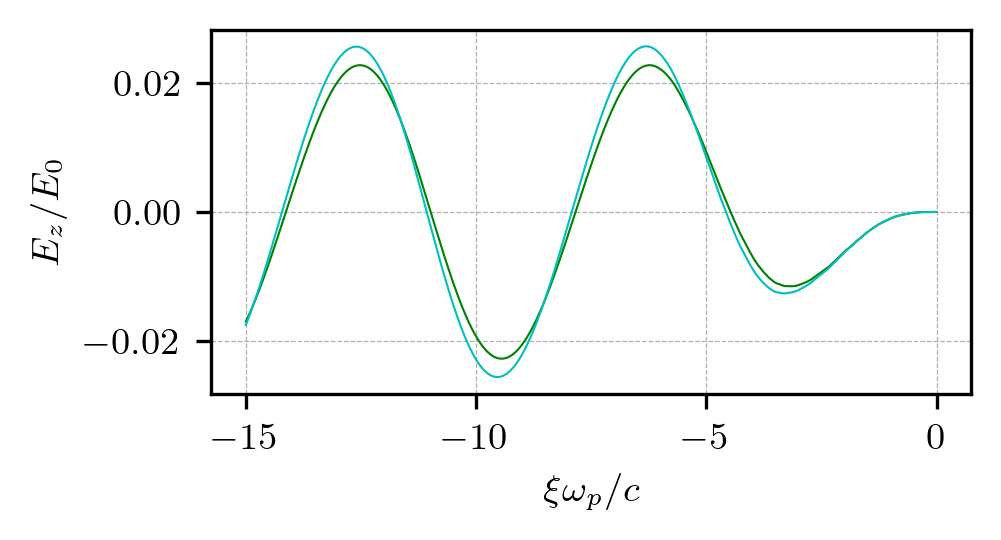

In [20]:
# Electric field on the axis

import numpy as np
import matplotlib.pyplot as plt

mm = 0.1/2.54
from matplotlib import rc, rcParams
rcParams["font.family"] = "Times New Roman"
rcParams["font.size"] = 9
rc('legend', fontsize=7)
rc('text', usetex=True)

def nplot(file, color='g'):
    fxi = np.load('diagnostics/' + file)
    plt.plot(fxi['xi'], fxi['Ez'], lw=0.5, color=color)

fig = plt.figure(figsize=(83*mm, 40*mm), dpi=300)
plt.grid(which='both', linestyle='--', linewidth=.3)
nplot('f_xi_00025.00.npz', 'g')
nplot('f_xi_00200.00.npz', 'c')

plt.ylabel(r'$E_{z}/E_{0}$')
plt.xlabel(r'$\xi\omega_{p}/c$')
plt.savefig('Ez.png', format='png', dpi=300, bbox_inches='tight')

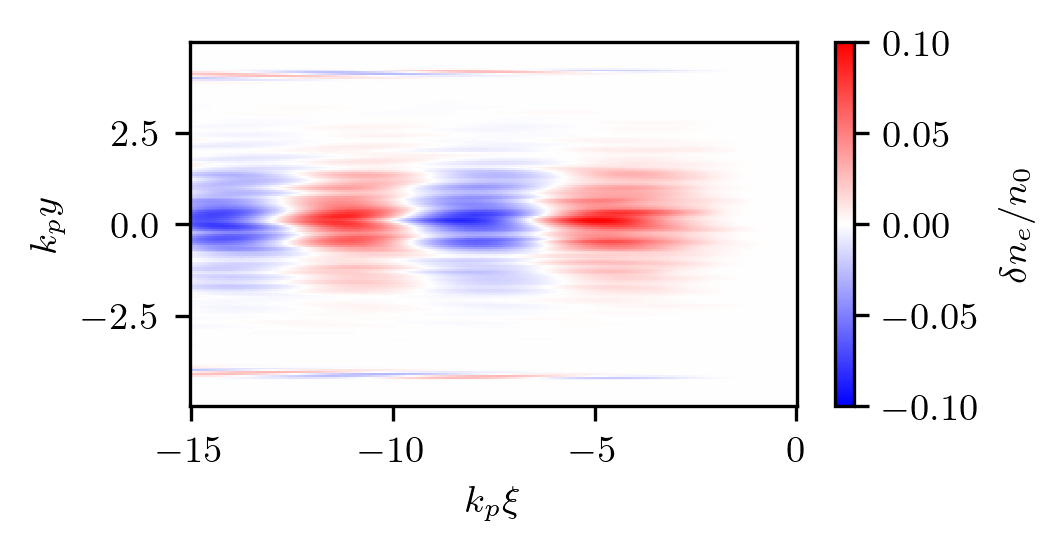

In [12]:
# Perturbation of the electron density that look noisy because of low number of macroparticles in the beam

ampl = 0.1
def fragment(workdir, time=25):
    cmap = np.load(workdir + f'diagnostics/colormaps_{time:05d}.00.npz')
    ro = (cmap['rho'].T)
    xis = cmap['xi']
    xs = cmap['transverse_grid']
    plt.pcolormesh(xis, xs, -ro, cmap='bwr', vmin=-ampl, vmax=ampl, rasterized=True)
    plt.colorbar(label=r'$\delta n_e / n_0$', orientation="vertical")
    plt.ylabel(r'$k_p y$')

fig = plt.figure(figsize=(83*mm, 40*mm), dpi=300)
fragment("", 200)
plt.xlabel(r'$k_p \xi$')
plt.savefig('ne.png',format='png', dpi=300, bbox_inches='tight')

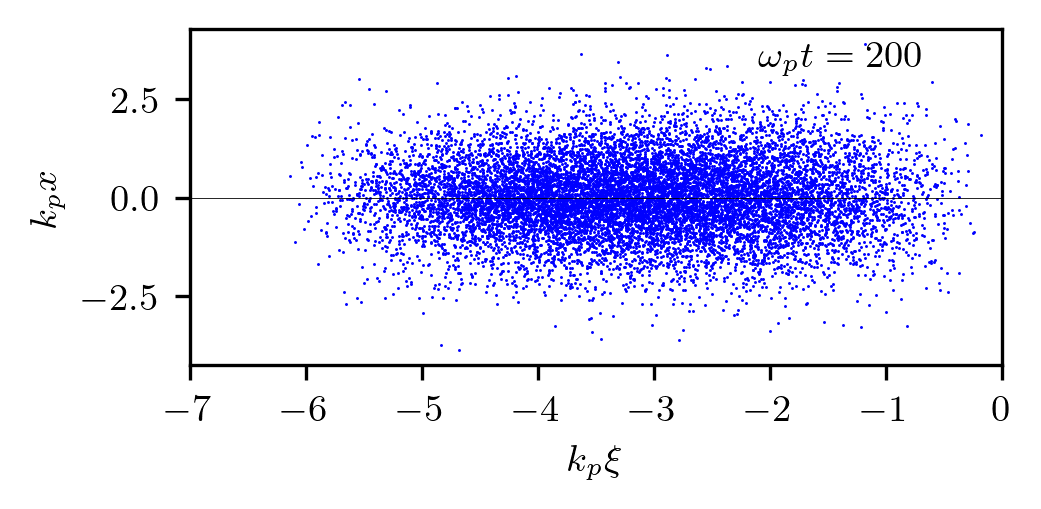

In [18]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
import gc
from IPython.display import clear_output

rc('text', usetex=True)
rcParams["font.family"] = "Times New Roman"
rcParams["font.size"] = 9
rc('legend', fontsize=7)
mm = 0.1/2.54

files = sorted([i for i in os.listdir('run_states/') if (i.endswith('.npz') and i.startswith('beamfile_'))])
for file in files:
    time = float(file[9:17])
    fig = plt.figure(figsize=(85*mm, 40*mm), dpi=300)
    beam_3d = np.load(workdir + "run_states/" + file)
    plt.scatter(beam_3d['xi'], beam_3d['x'], lw = 0, s = 0.5, c = 'b')
    plt.axhline(y=0, lw = 0.2, color = 'k')
    plt.ylabel(r'$k_p x$')
    plt.xlim(-7,0)
    plt.xlabel(r'$k_p \xi$')
    ax=plt.gca()
    plt.text(0.7, 0.89, f'$\omega_p t={time:.0f}$', transform=ax.transAxes, c='k')

    plt.tight_layout(pad=0.3)
    plt.savefig('beampart_' + file[9:14] + '.png', format='png', bbox_inches='tight', pad_inches = 0.02)
    plt.show()
    plt.close()
    clear_output(wait=True)
    gc.collect()


In [19]:
import os

import imageio.v2 as imageio

def ani(figtype):
    images = []
    files = sorted([i for i in os.listdir('.') if (i.startswith(figtype) and (i.endswith('.png'))) ])
    for filename in files:
        images.append(imageio.imread(filename))
    imageio.mimwrite(figtype + '.gif', images, loop=0)

ani('beampart')
